In [5]:
import os
os.getcwd()

'C:\\Users\\NGC'

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')
df.fillna({'TotalCharges':df['TotalCharges'].median()}, inplace = True)

df['Churn'] = df['Churn'].map({'Yes' : 1,'No' : 0})

print("Cleaned Shape:",df.shape)

(7043, 21)
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod

In [9]:
# 1. Overall churn rate
churn_rate = df['Churn'].mean() * 100
print(f"Overall Churn Rate: {churn_rate:.1f}%")

# 2. Churn by Contract Type
contract_churn = df.groupby('Contract')['Churn'].mean() * 100
print(contract_churn)

# 3. Churn by Tenure bucket
df['tenure_group'] = pd.cut(df['tenure'], 
                             bins=[0,12,24,48,72], 
                             labels=['0-12 months','13-24 months','25-48 months','49-72 months'])
tenure_churn = df.groupby('tenure_group',observed = False)['Churn'].mean() * 100
print(tenure_churn)

# 4. Churn by Payment Method
payment_churn = df.groupby('PaymentMethod')['Churn'].mean() * 100
print(payment_churn)

Overall Churn Rate: 26.5%
Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn, dtype: float64
tenure_group
0-12 months     47.678161
13-24 months    28.710938
25-48 months    20.388959
49-72 months     9.513176
Name: Churn, dtype: float64
PaymentMethod
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Electronic check             45.285412
Mailed check                 19.106700
Name: Churn, dtype: float64


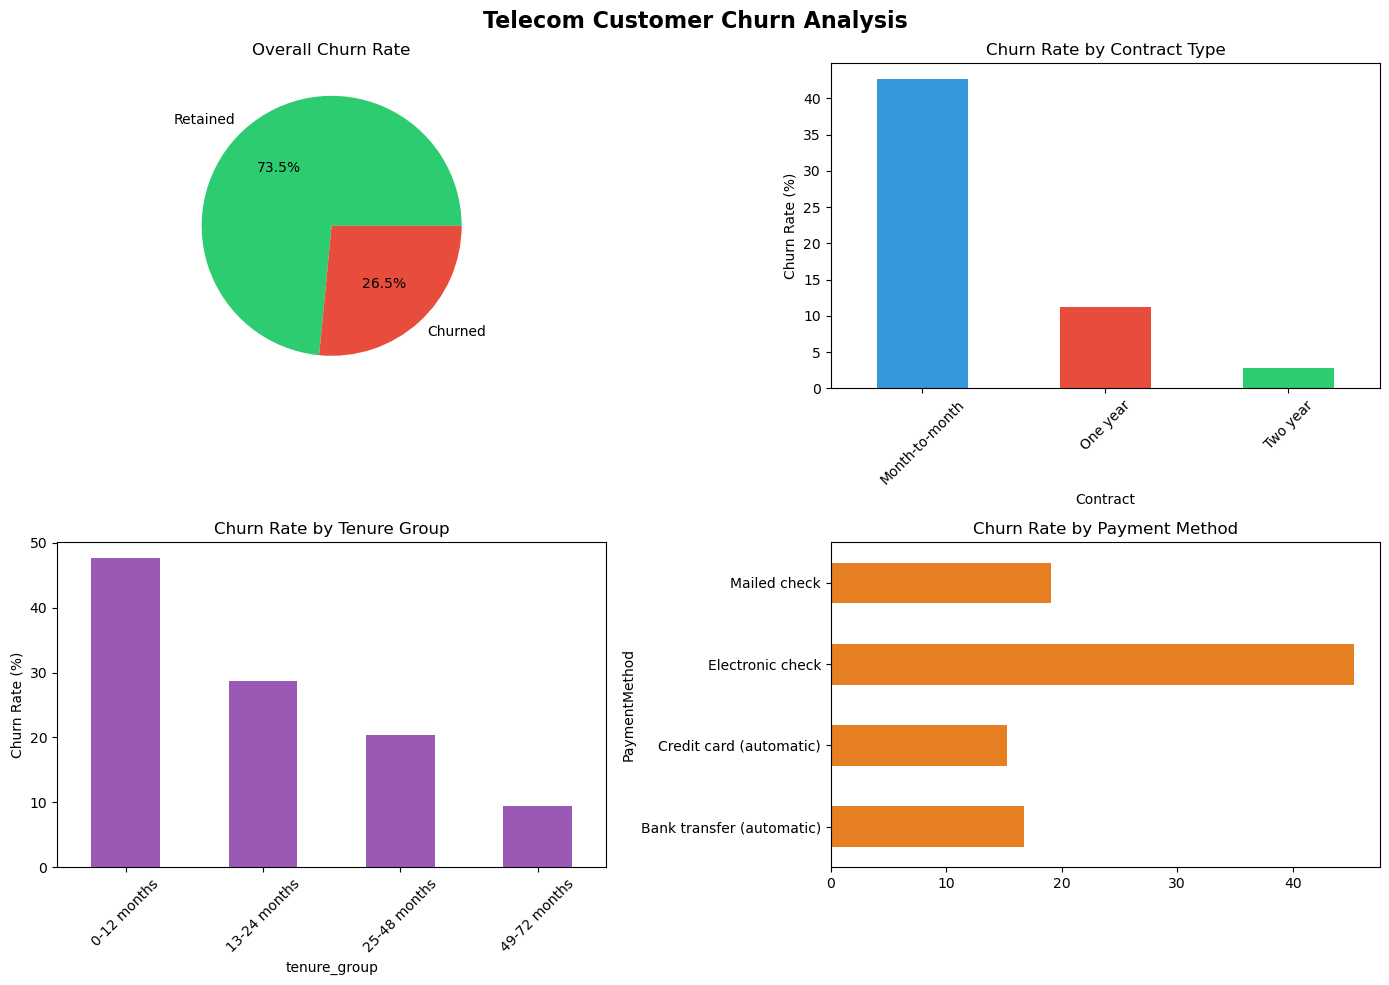

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Telecom Customer Churn Analysis', fontsize=16, fontweight='bold')

# Chart 1 — Churn Distribution
axes[0,0].pie([df['Churn'].value_counts()[0], df['Churn'].value_counts()[1]], 
               labels=['Retained','Churned'], autopct='%1.1f%%', colors=['#2ecc71','#e74c3c'])
axes[0,0].set_title('Overall Churn Rate')

# Chart 2 — Churn by Contract
contract_churn.plot(kind='bar', ax=axes[0,1], color=['#3498db','#e74c3c','#2ecc71'])
axes[0,1].set_title('Churn Rate by Contract Type')
axes[0,1].set_ylabel('Churn Rate (%)')
axes[0,1].tick_params(axis='x', rotation=45)

# Chart 3 — Churn by Tenure
tenure_churn.plot(kind='bar', ax=axes[1,0], color='#9b59b6')
axes[1,0].set_title('Churn Rate by Tenure Group')
axes[1,0].set_ylabel('Churn Rate (%)')
axes[1,0].tick_params(axis='x', rotation=45)

# Chart 4 — Churn by Payment Method
payment_churn.plot(kind='barh', ax=axes[1,1], color='#e67e22')
axes[1,1].set_title('Churn Rate by Payment Method')

plt.tight_layout()
plt.savefig('churn_analysis.png', dpi=150)
plt.show()

In [11]:
df.to_csv('Churn_Cleaned.csv' , index = False)